### Whats this about:
This notebook explores working with actigraphy time series recordings to get an idea of the data at hand.
- Investigate data quality (e.g., time gaps, non-wear periods, battery issues)
- Calculate main statistics for all participants
- Derive meaningful insights for feature engineering (circadian rhythms, time-based activity trends, activity levels, etc.)

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os

Function to plot ENMO, Angle Z, Light and any other column on below each other.

In [2]:
def plot_series_data(df, col='non-wear_flag',
                     label='Worn (0 = Worn, 1 = Not Worn)',
                     title='Non-Wear Flag',
                     x_col='day_time', x_label='Day Relative to PCIAT + Time'):
    plt.figure(figsize=(18, 12))
    
    # ENMO
    plt.subplot(4, 1, 1)
    plt.scatter(df[x_col], df['enmo'], label='ENMO', color='green', s=1)
    plt.title('ENMO (Euclidean Norm Minus One)')
    plt.ylabel('Movement Intensity')

    # Angle Z
    plt.subplot(4, 1, 2)
    plt.scatter(df[x_col], df['anglez'], label='Angle Z', color='blue', s=1)
    plt.title('Angle Z')
    plt.ylabel('Angle (degrees)')

    # Light
    plt.subplot(4, 1, 3)
    plt.scatter(df[x_col], df['light'], label='Light', color='orange', s=1)
    plt.title('Ambient Light')
    plt.ylabel('Light (lux)')

    # Any other column
    plt.subplot(4, 1, 4)
    plt.scatter(df[x_col], df[col], label=col, color='red', s=1)
    plt.title(f'{title}')
    plt.ylabel(f'{label}')
    plt.xlabel(f'{x_label}')

    plt.tight_layout()
    plt.show()

## One participant data preview

In [3]:
train = pd.read_csv(r'..\data\child-mind-institute-problematic-internet-use\train.csv')

In [4]:
path = '..\data\child-mind-institute-problematic-internet-use\series_train.parquet\id=0417c91e'
series_train = pd.read_parquet(path)
series_train

,step,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,time_of_day,weekday,quarter,relative_date_PCIAT
0,0,0.014375,-0.020112,-0.995358,0.001060,-88.445251,0.0,41.000000,4195.000000,44100000000000,2,2,5.0
1,1,0.014167,-0.023278,-0.996164,0.000289,-88.372200,0.0,41.000000,4194.833496,44105000000000,2,2,5.0
2,2,0.014036,-0.022964,-0.996320,0.000301,-88.356422,0.0,41.500000,4194.666504,44110000000000,2,2,5.0
3,3,0.013593,-0.022048,-0.996762,0.002278,-88.575943,0.0,37.500000,4194.500000,44115000000000,2,2,5.0
4,4,-0.061772,-0.065317,-0.973063,0.092321,-88.391273,0.0,55.666668,4199.000000,44780000000000,2,2,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
287174,287174,-0.407433,0.091612,-0.377763,0.039733,-43.319416,0.0,7.000000,3695.000000,32875000000000,1,3,53.0
287175,287175,-0.703572,0.016187,0.159560,0.035980,14.121390,0.0,7.000000,3695.000000,32880000000000,1,3,53.0
287176,287176,-0.209607,-0.469700,0.636573,0.097799,44.998573,0.0,7.000000,3695.000000,32885000000000,1,3,53.0
287177,287177,-0.390378,0.284386,0.147654,0.057826,7.726313,0.0,7.000000,3695.000000,32890000000000,1,3,53.0


The description of the actigraphy data columns and comments below each one:

series_{train|test}.parquet/id={id} - Series to be used as training data, partitioned by id. Each series is a continuous recording of accelerometer data for a single subject spanning many days.

- id - The patient identifier corresponding to the id field in train/test.csv.
- step - An integer timestep for each observation within a series. Corresponds to sequential data collection points.

- X, Y, Z - Measure of acceleration, in g, experienced by the wrist-worn watch along each standard axis.
The three-dimensional accelerometer readings, describe the physical movement of the person wearing the device

- enmo - As calculated and described by the wristpy package, ENMO is the Euclidean Norm Minus One of all accelerometer signals (along each of the x-, y-, and z-axis, measured in g-force) with negative values rounded to zero. Zero values are indicative of periods of no motion. While no standard measure of acceleration exists in this space, this is one of the several commonly computed features.

A scalar value for the level of motion, where higher values indicate more activity, and zeros - of no motion

- anglez - As calculated and described by the wristpy package, Angle-Z is a metric derived from individual accelerometer components and refers to the angle of the arm relative to the horizontal plane.

Provide information about posture or how the arm is positioned during the activity

- non-wear_flag - A flag (0: watch is being worn, 1: the watch is not worn) to help determine periods when the watch has been removed, based on the GGIR definition, which uses the standard deviation and range of the accelerometer data.

Would be great to know how it was calculated.

- light - Measure of ambient light in lux. See [here](https://actigraphcorp.my.site.com/support/s/article/Lux-Measurements) for details.
May help distinguish between different times of day (day vs. night) or types of activities (e.g., being indoors or outdoors)

- battery_voltage - A measure of the battery voltage in mV.

Unlikely to be important for modeling, but may help in identifying issues related to the data collection process (low battery voltage might align with gaps, inconsistencies, or interruptions in the data)

- time_of_day - Time of day representing the start of a 5s window that the data has been sampled over, with format %H:%M:%S.%9f.

Again as @AmbrosM have been already said, this description is not true. Time of the day was measured in nanoseconds since midnight.

- weekday - The day of the week, coded as an integer with 1 being Monday and 7 being Sunday.

This could provide insights into behavior patterns during weekdays versus weekends

- quarter - The quarter of the year, an integer from 1 to 4.

Could be relevant if there are seasonal patterns in activity (e.g., more outdoor activity in summer)

- relative_date_PCIAT - The number of days (integer) since the PCIAT test was administered (negative days indicate that the actigraphy data has been collected before the test was administered).

The mentioned Wristpy package is here: [Wrist-Worn Accelerometer Data Processing](https://github.com/childmindresearch/wristpy)

In [5]:
participant_id = path.split('\\')[-1].split('=')[-1]
participant_id

'0417c91e'

In [6]:
train[train['id'] == participant_id]

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
68,0417c91e,Spring,6,1,Winter,40.0,Summer,15.484507,45.5,45.6,...,0.0,0.0,0.0,11.0,NaN,NaN,NaN,Summer,0.0,0.0


Plot data by steps:

So we'll look at the data collected from a 6-year-old girl, with no data on sleep or activity based on Physical Activity Questionnaire, who spends no time on the Internet and has an SII of 0.

Her physical data includes a BMI of 15.48, height of 45.5 inches, and weight of 45.6 pounds, normal blood pressure readings (Systolic: 115, Diastolic: 73), and a heart rate of 86 bpm

The fitness endurance test shows a max stage of 6, with a duration of 9 minutes and 5 seconds.

The girl completed a small number of curl-ups, no push-ups, and had moderate sit-and-reach flexibility on both sides. There is missing data for grip strength tests, and the participant's trunk lift performance is in zone 1.0

A CGAS score of 40 suggests that the child has significant impairment in daily functioning

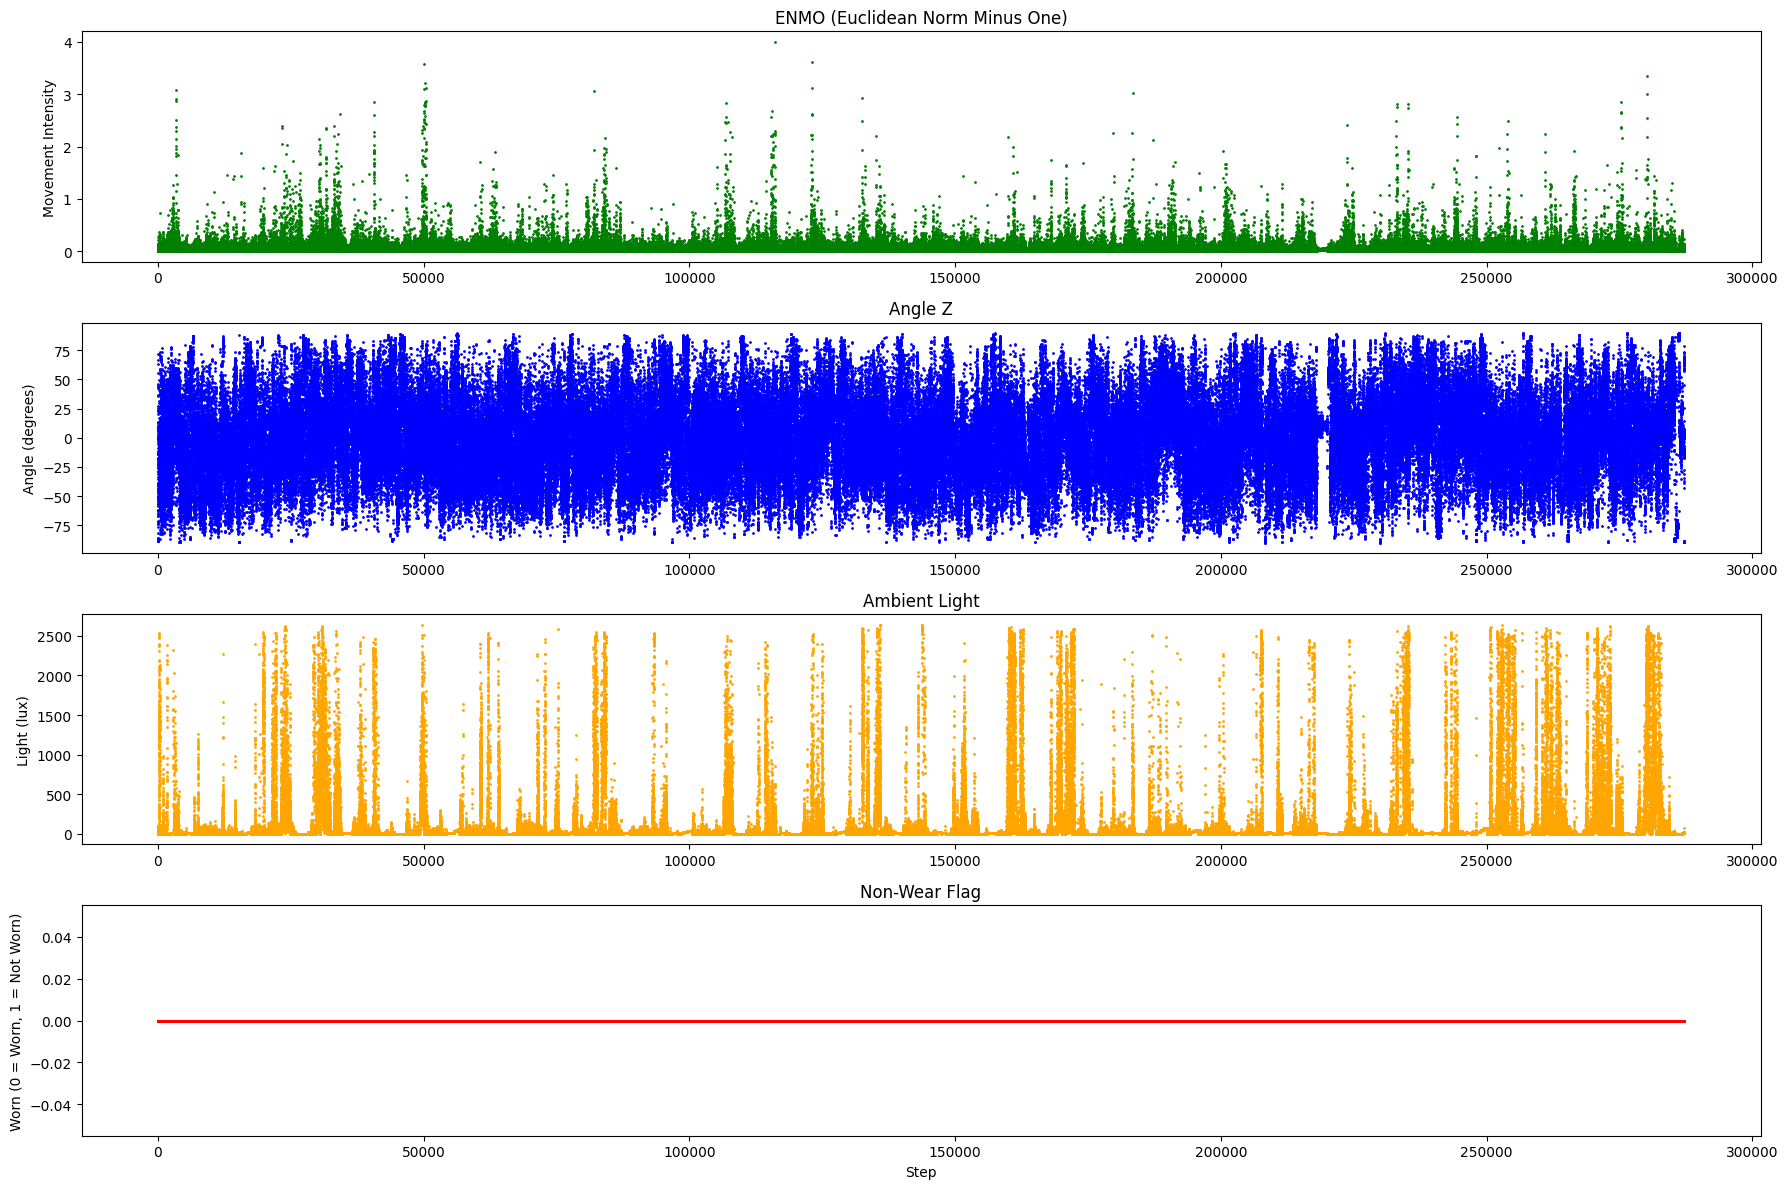

In [7]:
plot_series_data(series_train, x_col='step', x_label='Step')

 Note: Looks ok, and the wear flag looks correct (always indicating that the device was worn). But when using the step column as the x-axis, the time points are assumed to be equidistant, meaning that each step represents a uniform interval (e.g., every 5 seconds). But in reality, there may be irregular time gaps between data points.
 
Create a continuous time scale in days by transforming the time_of_day column (which is in nanoseconds) to hours and then combining it with relative_date_PCIAT:

In [8]:
series_train['time_of_day_hours'] = (
    series_train['time_of_day'] / 1e9 / 3600 #nanoseconds to hours
)
series_train['day_time'] = series_train['relative_date_PCIAT'] + (
    series_train['time_of_day_hours'] / 24
)
series_train['day_time']

0          5.510417
1          5.510475
2          5.510532
3          5.510590
4          5.518287
            ...    
287174    53.380498
287175    53.380556
287176    53.380613
287177    53.380671
287178    53.380729
Name: day_time, Length: 287179, dtype: float64

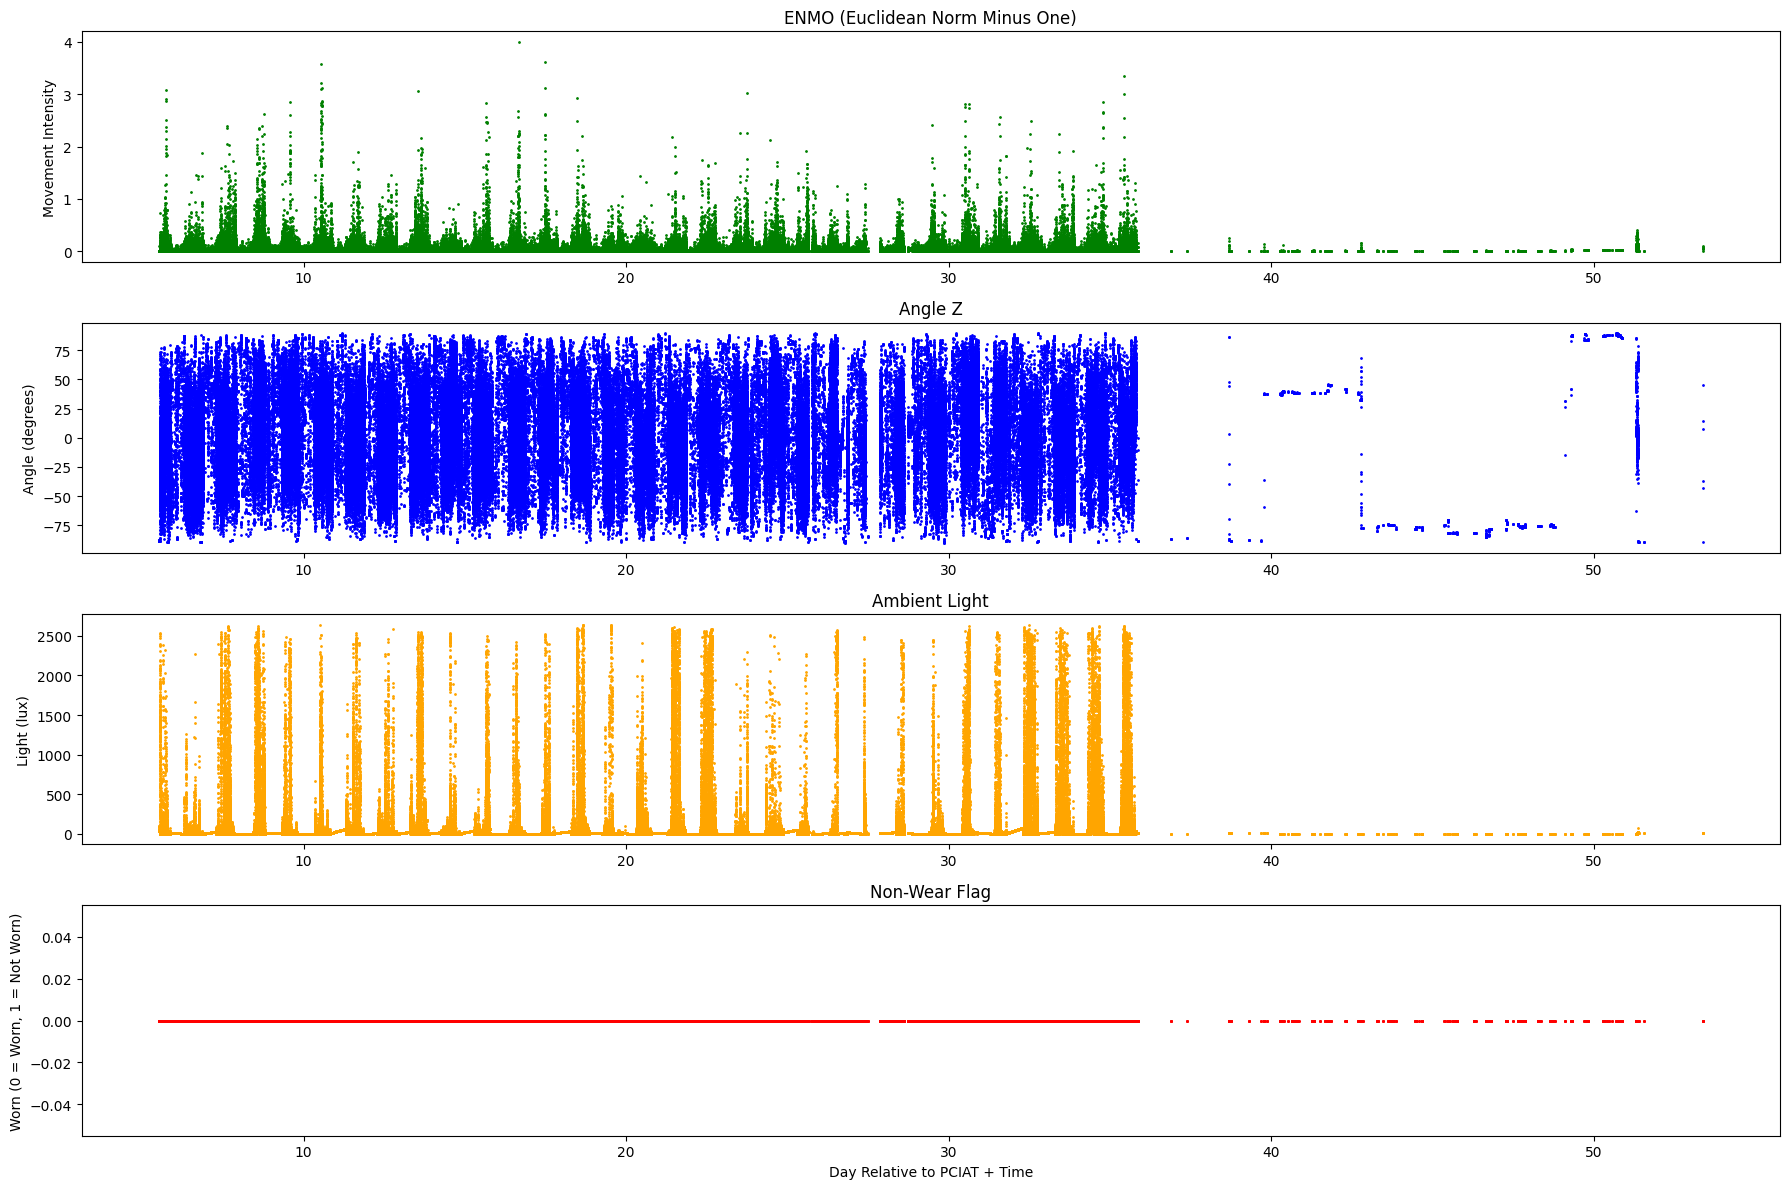

In [9]:
plot_series_data(series_train, x_col='day_time', x_label='Day Relative to PCIAT + Time')

In [10]:
len(series_train[series_train['relative_date_PCIAT'] > 36])

1830

Note: Here, the data is plotted with real time on the x-axis, revealing gaps (especially on the right end) - the data for a few last weeks (after day 36) is only 1,830 measurements out of 287,179. These gaps suggest that some data was either not collected at all or was intentionally cut. Let's zoom in.

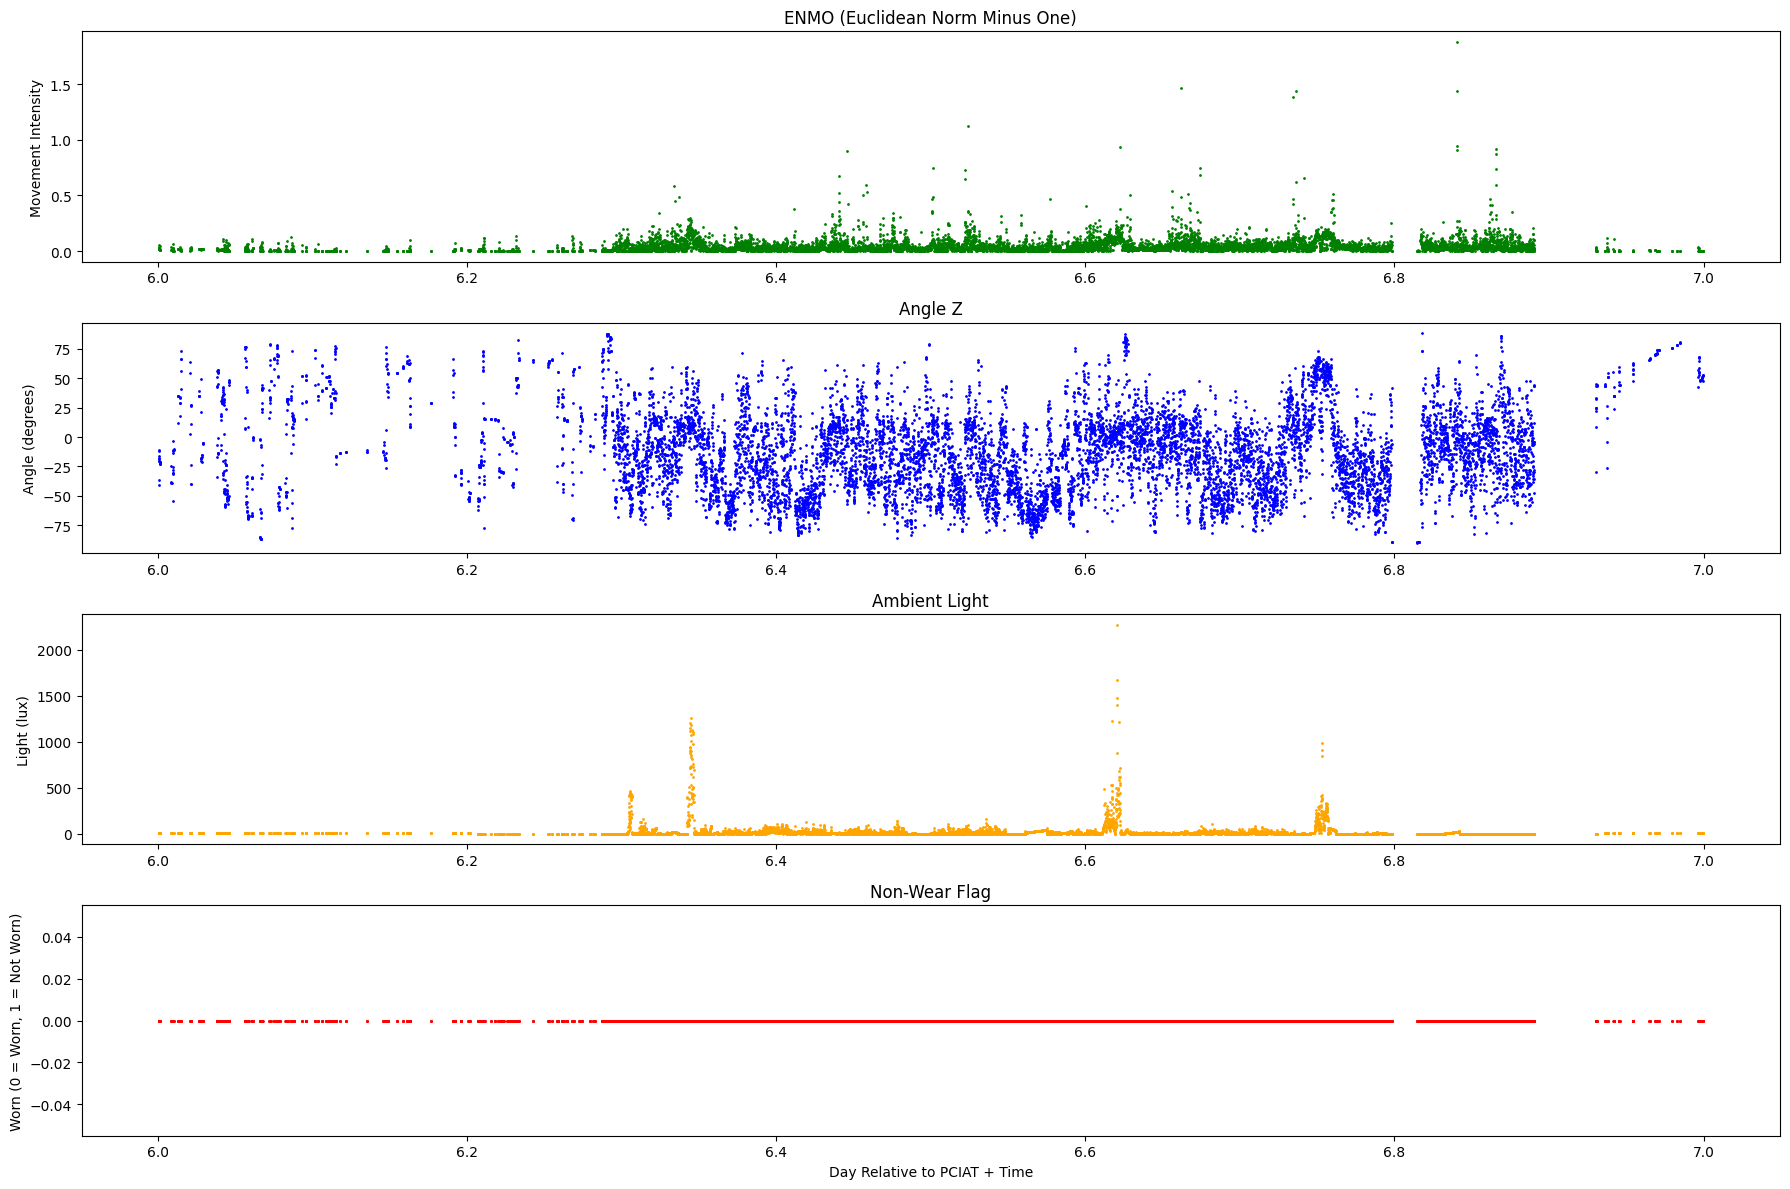

In [11]:
start_day = 2 # second day of wearing the device
show_days = 1

first_day = min(series_train['relative_date_PCIAT']) + start_day - 1
filtered_data = series_train[
    (series_train['relative_date_PCIAT'] >= first_day) &
    (series_train['relative_date_PCIAT'] <= first_day + show_days - 1)
].copy()

plot_series_data(filtered_data)

Note:
The left part of the plot likely represents sleep time.
The activity level peaks in the middle of the day.
The spikes in the ENMO, Angle Z, and Ambient Light suggest short bursts of activity that may correspond to specific tasks or movements, but there are many periods of low or no movement, and the overall pattern of activity appears to be consistent with significant impairment in daily functioning according to the CGAS score.
For a healty child of this age, you would generally expect to see more consistent periods of active movement throughout the day, especially during the daytime hours when children typically play, run, etc.

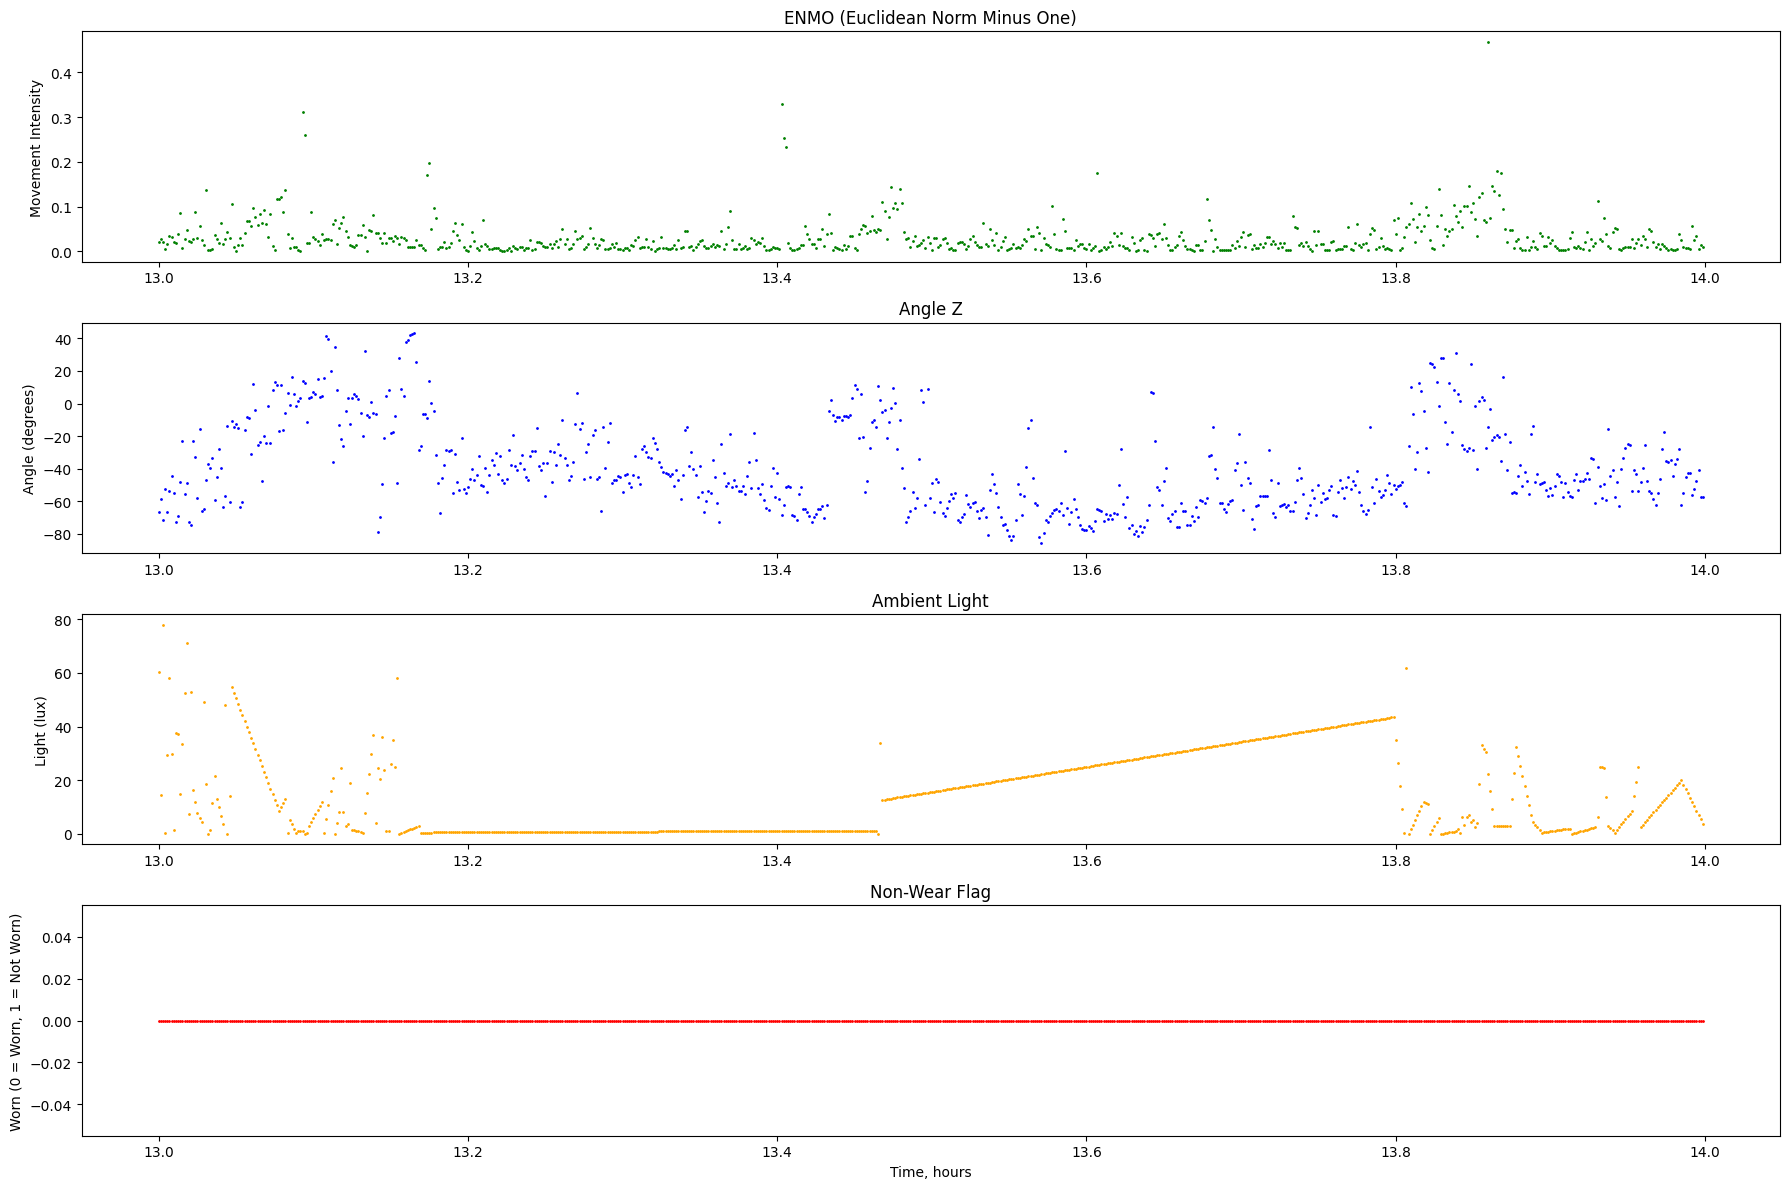

In [12]:
show_day = 2 # show second day
hour_from = 13 # starting from 1 pm
hour_to = 14 # to 2 pm

show_day = min(series_train['relative_date_PCIAT']) + show_day - 1
filtered_data = series_train[
    (series_train['relative_date_PCIAT'] == show_day) &
    (series_train['time_of_day_hours'] >= hour_from) & 
    (series_train['time_of_day_hours'] < hour_to)
].copy()

plot_series_data(filtered_data, x_col='time_of_day_hours', x_label='Time, hours')

 Note:
The ENMO (Euclidean Norm Minus One) shows small but continuous movement, and there are changes in orientation, indicating that even minor movements are detected, which can be interpreted as the device being worn.
The same is true if we look at any day within the last 2 weeks, where there are few measurements left, yet the worn flag seems to align well with movement patterns.
The light data in this part of the plot does not look completely consistent or reliable, especially because of the flatline, linear trend in the middle and sudden changes (data processing artifacts?).
Maybe the data has been truncated for periods of low battery? Let's check the battery voltage over time.

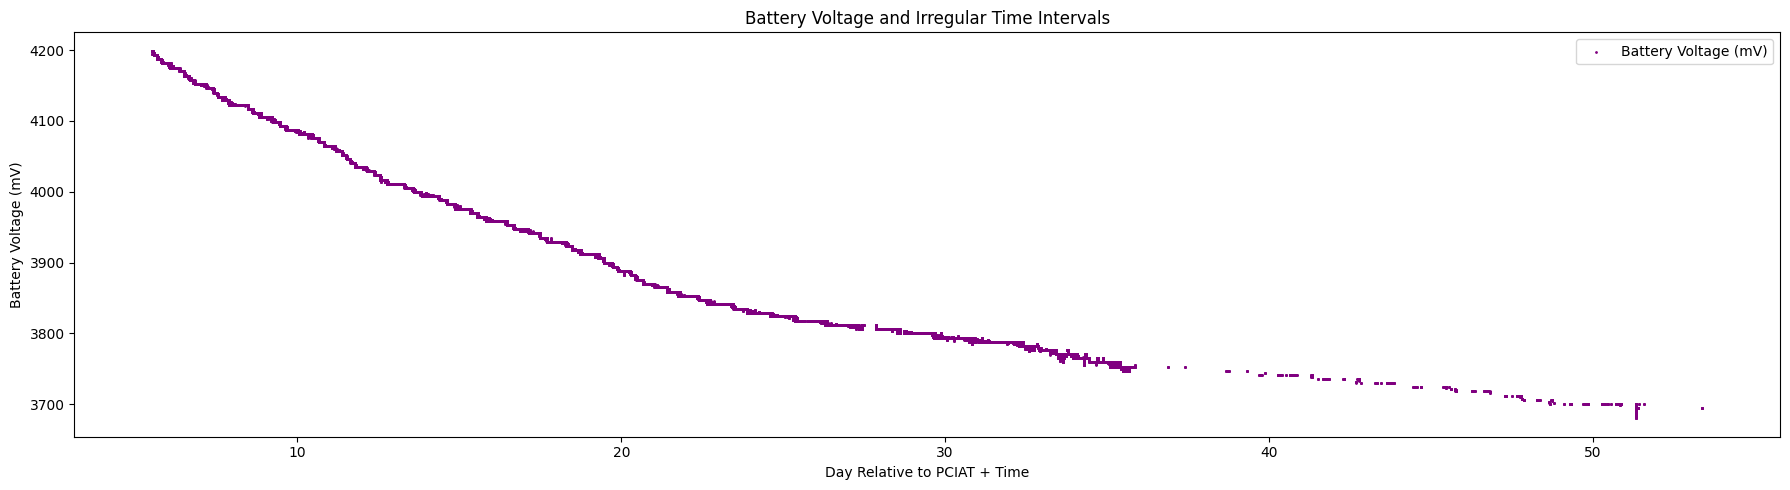

In [13]:
plt.figure(figsize=(18, 5))

plt.scatter(series_train['day_time'], series_train['battery_voltage'], 
            color='purple', label='Battery Voltage (mV)', s=1)

plt.xlabel('Day Relative to PCIAT + Time')
plt.ylabel('Battery Voltage (mV)')
plt.title('Battery Voltage and Irregular Time Intervals')
plt.legend()

plt.tight_layout()
plt.show()

Note: The battery did not seem to run out completely at the end. I guess, the smooth decline suggests that the device was likely functioning properly during this time.

### Day/nigth periods